Diabetes Prediction using K-Nearest Neighbors (KNN)
Algorithm Overview
The K-Nearest Neighbors (KNN) algorithm is a supervised machine learning model used for classification. It works on the principle of feature similarity: it classifies a new data point based on how its neighbors are classified. For this diabetes dataset, the model will look at a new patient's health metrics, find the 'K' number of historical patients with the most similar metrics, and predict the diabetes outcome based on the majority diagnosis of those neighbors.

Dataset Shape: (768, 9)

--- Data Characteristics ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


C:\Users\Admin\AppData\Local\Temp\ipykernel_11620\674548462.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


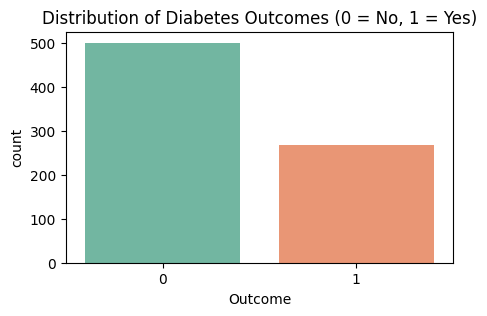

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

# Exploratory Data Analysis (EDA)
print("Dataset Shape:", df.shape)
print("\n--- Data Characteristics ---")
print(df.info())

# Visualize the target variable distribution
plt.figure(figsize=(5, 3))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Distribution of Diabetes Outcomes (0 = No, 1 = Yes)')
plt.show()

In [ ]:
# 1. Handle Missing Data (Zeros)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Fill missing values with the median
for col in cols_with_zeros:
    df[col] = df[col].fillna(df[col].median())

# 2. Split into Features (X) and Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']   

# 3. Scale the Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-Test Split (20% test size)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (614, 8)
Testing features shape: (154, 8)


k=3 | Mean CV Accuracy: 72.97%
k=5 | Mean CV Accuracy: 75.25%
k=7 | Mean CV Accuracy: 75.42%
k=9 | Mean CV Accuracy: 76.23%


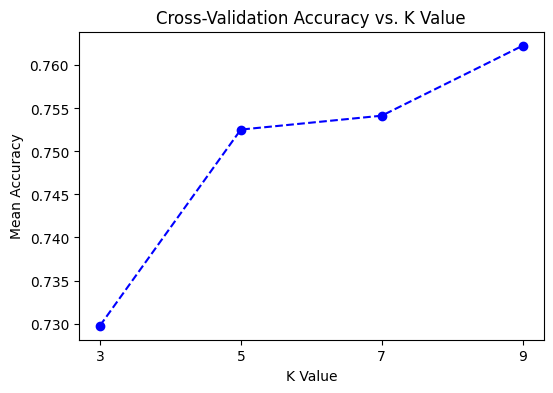


Optimal K value chosen: 9


In [36]:
# Test multiple k values using cross-validation to find the optimal model
k_values = [3, 5, 7, 9]
cv_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # Perform 5-fold cross validation
    scores = cross_val_score(knn_temp, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"k={k} | Mean CV Accuracy: {scores.mean() * 100:.2f}%")

# Plot the CV scores to visualize the best K
plt.figure(figsize=(6, 4))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed', color='blue')
plt.title('Cross-Validation Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Accuracy')
plt.xticks(k_values)
plt.show()

# Select the best K based on the highest CV score
best_k = k_values[np.argmax(cv_scores)]
print(f"\nOptimal K value chosen: {best_k}")

Final Test Accuracy: 72.08%

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79       100
           1       0.61      0.57      0.59        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154



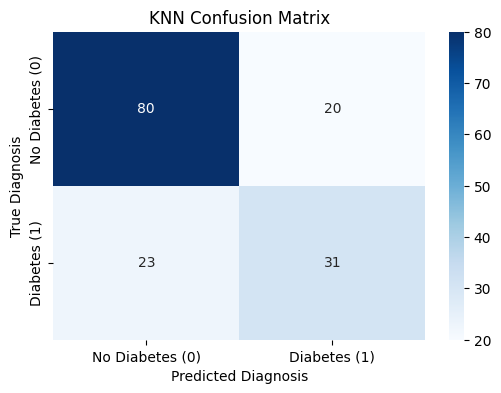

In [37]:
# Train the final model with the optimal K
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

# Make predictions on the unseen test data
y_pred = final_knn.predict(X_test)

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Final Test Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", class_report)

# Plot the Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'], 
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.xlabel('Predicted Diagnosis')
plt.ylabel('True Diagnosis')
plt.title('KNN Confusion Matrix')
plt.show()